## Ejemplo inicial de aprendizaje no supervisado: clustering con datos sintéticos

En este ejemplo trabajaremos con un conjunto de datos **sintético**, es decir, generado artificialmente, que **no contiene etiquetas**.  
El objetivo es ilustrar de manera visual cómo funcionan los algoritmos de **aprendizaje no supervisado**, en particular los algoritmos de **clustering**.

El clustering busca identificar **grupos naturales** en los datos a partir de la similitud entre las observaciones, sin utilizar una variable objetivo previa.

En este primer ejercicio:
- Cada observación tiene dos variables (coordenadas en el plano).
- No conocemos cuántos grupos existen a priori.
- Exploraremos visualmente la estructura de los datos antes de aplicar cualquier algoritmo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs


# Generación de datos sintéticos sin etiquetas
X, _ = make_blobs(
    n_samples=2000,
    centers=10,
    cluster_std=3,
    random_state=42
)


## Representación de los datos en forma de tabla

En la práctica, los datos con los que se trabaja en Machine Learning **no se presentan como puntos en una gráfica**, sino como **tablas**, donde:
- Cada fila representa una observación.
- Cada columna representa una variable.

Antes de realizar cualquier análisis o visualización, es fundamental **organizar los datos en una estructura tabular**, generalmente usando un *DataFrame*.

A continuación, convertiremos los datos sintéticos en una tabla para observar su estructura.


In [2]:
# Creación del DataFrame
df = pd.DataFrame(X, columns=["Variable_1", "Variable_2"])

# Mostrar las primeras filas
df.head(10)

,Variable_1,Variable_2
0,-6.626307,9.170344
1,-12.233000,5.941123
2,-5.696589,-0.001766
3,-12.263395,6.742545
4,-4.733063,-5.732479
5,-5.087427,-4.776591
6,-14.346944,8.847497
7,-6.411020,-1.419720
8,-4.297979,9.215958
9,-5.196564,-5.577489


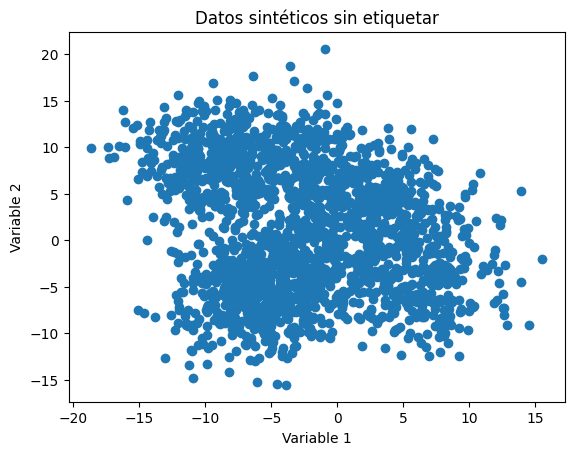

In [3]:
# Visualización inicial de los datos
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Datos sintéticos sin etiquetar")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()

### Interpretación inicial de los datos

En la gráfica anterior observamos un conjunto de puntos distribuidos en el plano, sin ningún tipo de coloración o etiqueta que indique a qué grupo pertenece cada uno.

Aunque visualmente podemos intuir la existencia de varias agrupaciones, **el algoritmo no tiene esta información**.  
En el aprendizaje no supervisado, el modelo debe **descubrir por sí mismo** la estructura subyacente en los datos, basándose únicamente en la distancia o similitud entre las observaciones.

En el siguiente paso aplicaremos un algoritmo de clustering para identificar automáticamente estos grupos.


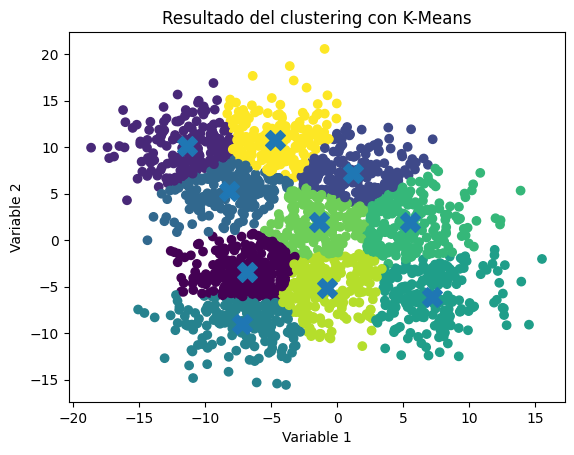

In [4]:
from sklearn.cluster import KMeans

# Definición del modelo K-Means
kmeans = KMeans(n_clusters=10, random_state=42)

# Ajuste del modelo y predicción de clusters
labels = kmeans.fit_predict(X)

# Visualización de los clusters obtenidos
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)
plt.title("Resultado del clustering con K-Means")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.show()


### Análisis del clustering obtenido

El algoritmo K-Means ha dividido automáticamente los datos en tres grupos o *clusters*, asignando cada observación al centroide más cercano.

Aspectos importantes a tener en cuenta:
- Los colores representan **grupos descubiertos**, no clases reales.
- El número de clusters fue definido previamente mediante el parámetro `n_clusters`.
- K-Means funciona mejor cuando los grupos son compactos y aproximadamente esféricos.
- Si se modifica el número de clusters, la estructura resultante cambia.

Este ejemplo muestra cómo el aprendizaje no supervisado permite encontrar patrones en los datos sin necesidad de etiquetas previas.


Puedes usar el siguiente archivo, en caso tal que sepas manejar Blender, para visualizar los datos en 3D:
https://uniminuto0-my.sharepoint.com/:u:/g/personal/rmurielrodr_uniminuto_edu_co/IQCZEN1McfxVTY7-PT4Bi8ErASaeCE99pXmerM9huSEKNGk?e=NAUMRY

## Dataset Iris para aprendizaje no supervisado (clustering)

En este ejercicio utilizaremos el **dataset Iris**, un conjunto de datos clásico en Machine Learning que contiene mediciones morfológicas de flores del género *Iris*.  
Aunque el dataset original incluye una etiqueta de especie (clase), en este punto **no la utilizaremos**, porque el objetivo es trabajar desde el enfoque de **aprendizaje no supervisado**.

El dataset **Iris** fue recolectado a finales de los años 30 por **Edgar Anderson** y publicado por **Ronald A. Fisher** en **1936** con el objetivo de ilustrar métodos estadísticos.

- Los datos fueron **medidos físicamente en flores reales**.
- Incluye **tres especies reales** del género *Iris*.
- Contiene **mediciones morfológicas reales**, correspondientes al **sépalo** y al **pétalo** de cada flor.


### ¿Qué contiene el dataset?
El dataset tiene **150 observaciones** (filas) y **4 características numéricas** (variables) por observación:

1. `sepal length (cm)` – longitud del sépalo  
2. `sepal width (cm)` – ancho del sépalo  
3. `petal length (cm)` – longitud del pétalo  
4. `petal width (cm)` – ancho del pétalo  

### ¿Qué son el sépalo y el pétalo?

Para comprender mejor las variables del dataset Iris, es importante conocer brevemente la estructura básica de una flor.

- **Sépalo**:  
  Es la parte externa de la flor, generalmente de color verde, cuya función principal es **proteger la flor cuando aún está en botón** (antes de abrirse).  
  En conjunto, los sépalos forman el **cáliz**.

- **Pétalo**:  
  Es la parte interna y más visible de la flor, usualmente de colores llamativos.  
  Su función principal es **atraer a los polinizadores** (insectos, aves, etc.).  
  En conjunto, los pétalos forman la **corola**.

En el dataset Iris se miden:
- **Longitud** y **ancho** del sépalo  
- **Longitud** y **ancho** del pétalo  

Estas medidas permiten capturar diferencias morfológicas entre flores, que posteriormente pueden ser analizadas mediante técnicas de aprendizaje no supervisado para identificar patrones o agrupaciones naturales.


### ¿Por qué no se puede graficar directamente en 2D o 3D?
Como los datos están en un espacio de **4 dimensiones**, no es posible representarlos de forma directa en un plano (2D) o en el espacio (3D) sin perder información.

### ¿Qué haremos entonces?
Aplicaremos una **reducción de dimensionalidad** para proyectar los datos a:
- **2D** o **3D** (para visualización y exploración)

Luego, sobre la representación (o sobre las variables originales), aplicaremos un algoritmo de clustering como **K-Means** para identificar agrupaciones sin usar etiquetas.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTv2-VJCoRwEo2j3sLr46TNd-Y5gd2-gjaxGw&s" width="500"/>



In [5]:
import pandas as pd
from sklearn.datasets import load_iris

# Cargar Iris desde sklearn
iris = load_iris()

# X: características (4 variables), y: etiqueta (NO se usará para clustering)
X = iris.data
feature_names = iris.feature_names

# Crear DataFrame con las 4 características
df = pd.DataFrame(X, columns=feature_names)

# Vista inicial del dataset
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Proyección a 2D mediante PCA (visualización)

El dataset Iris tiene **4 características**, por lo que cada observación vive en un espacio de **4 dimensiones**.  
Para poder **visualizar** la distribución de los datos, necesitamos proyectarlos a un espacio de menor dimensión.

Una técnica clásica para esto es **PCA (Análisis de Componentes Principales)**, que construye nuevas variables (componentes) como combinaciones lineales de las variables originales, buscando:

- Maximizar la **varianza** capturada en la proyección.
- Reducir la dimensionalidad conservando la mayor cantidad posible de información.

En este paso:
- Proyectaremos los datos de 4D a **2D** (dos componentes principales).
- Esta proyección es solo para **exploración visual**; no es clustering.


In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Aplicar PCA para reducir de 4D a 2D
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X)

# Guardar en un DataFrame para facilitar análisis
df_pca = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])


df_pca.head()


,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


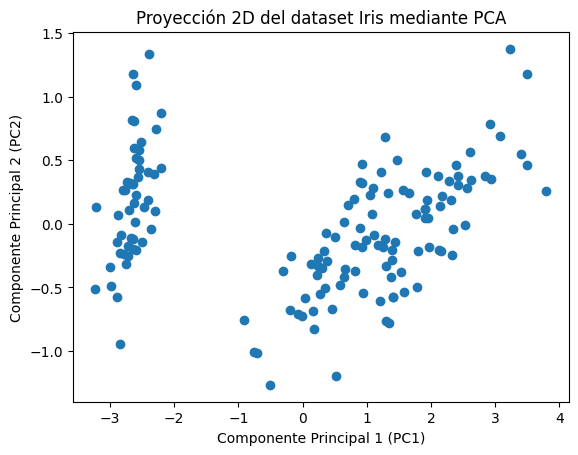

In [7]:
import matplotlib.pyplot as plt

# Gráfica de la proyección PCA en 2D
plt.figure()
plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")
plt.title("Proyección 2D del dataset Iris mediante PCA")
plt.show()


Si manejas blender puedes usar el siguiente archivo para visualizar en 3d

https://uniminuto0-my.sharepoint.com/:u:/g/personal/rmurielrodr_uniminuto_edu_co/IQCDyw2K58I3TpiWgWA2DLjaAaUz7xerszp-n1_dJHDTH1s?e=qlpxs8

## Aplicación de K-Means al dataset Iris

Una vez explorada la distribución de los datos mediante una proyección PCA, aplicaremos un algoritmo de **clustering** para identificar agrupaciones de forma automática.

En este caso utilizaremos **K-Means**, un algoritmo que:
- Busca dividir los datos en *k* grupos
- Asigna cada observación al centroide más cercano
- No utiliza etiquetas reales durante el proceso

Para el dataset Iris:
- No usamos la variable de especie
- Aplicamos K-Means sobre las **4 características originales**
- Usamos la proyección PCA únicamente para **visualizar el resultado**


In [8]:
from sklearn.cluster import KMeans

# Definir el modelo K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

# Ajustar el modelo a los datos originales (4D)
clusters = kmeans.fit_predict(X)

# Agregar el cluster asignado al DataFrame PCA (solo para visualización)
df_pca["cluster"] = clusters

df_pca.head()


,PC1,PC2,cluster
0,-2.684126,0.319397,1
1,-2.714142,-0.177001,1
2,-2.888991,-0.144949,1
3,-2.745343,-0.318299,1
4,-2.728717,0.326755,1


## Visualización del resultado del clustering

A continuación se muestra la proyección PCA en 2D, donde cada punto está coloreado según el cluster asignado por K-Means.

Es importante destacar que:
- Los colores representan **clusters encontrados**, no especies reales
- La separación observada depende tanto del algoritmo como de la proyección
- K-Means busca clusters aproximadamente esféricos


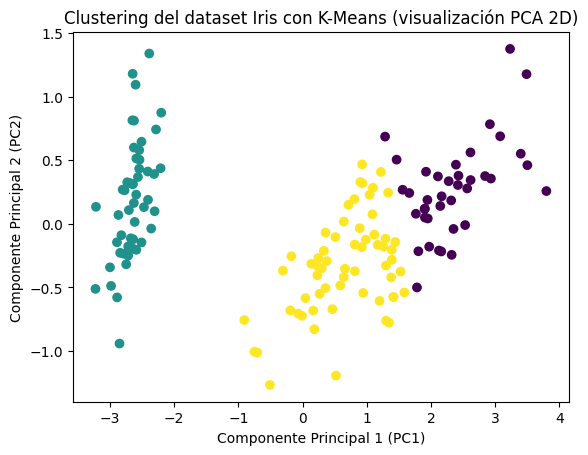

In [9]:
plt.figure()
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["cluster"]
)
plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")
plt.title("Clustering del dataset Iris con K-Means (visualización PCA 2D)")
plt.show()


### Interpretación inicial del clustering

Al observar la gráfica podemos notar que:
- Algunos clusters aparecen relativamente bien separados
- Otros muestran solapamiento, lo que indica mayor dificultad de agrupamiento
- El resultado depende del valor de *k* y de la estructura real de los datos

Este comportamiento es esperado en aprendizaje no supervisado, ya que:
- No existe una partición “correcta” única
- El clustering depende de supuestos geométricos del algoritmo
